# 수입식품 출연과제
## 식품으로 일부 변수를 가지고 확인하였으며 농축수산물도 확인 필요
## 중복데이터와 중복의 의미
### 접수번호 동일한 데이터 제거
### 동일한 데이터(X, y 가 동일) 데이터 제거
### y는 다른데 X가 동일한 데이터 제거, 살려?
<img src = 'https://images.unsplash.com/photo-1528812969535-4bcefc071532?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Nnx8c2FtZXxlbnwwfHwwfHw%3D&auto=format&fit=crop&w=500&q=60' >

In [163]:
pwd

'D:\\smart food\\scripts\\old'

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings('ignore')
# Imports
import pandas as pd
import numpy as np
import seaborn as sns; sns.set()
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        
    return tf

# Obtain data

In [44]:
path =r'D:\smart food\data'
import glob
glob.glob(path + '/*.pkl')

['D:\\smart food\\data\\20220310_조상구_무작위추출결과(21년 4분기).pkl',
 'D:\\smart food\\data\\20220310_조상구_수입실적 기본정보(21년 4분기).pkl',
 'D:\\smart food\\data\\df_0524.pkl',
 'D:\\smart food\\data\\paper.pkl',
 'D:\\smart food\\data\\가공식품_수입식품(16년~21년).pkl',
 'D:\\smart food\\data\\농.임산물_수입식품(16년~21년).pkl',
 'D:\\smart food\\data\\부적합파일_1990s-2021.pkl',
 'D:\\smart food\\data\\제조공정.pkl']

In [40]:
df = pd.read_pickle(path + '/부적합파일_1990s-2021.pkl')
df.head()
df.shape
df['판정결과'].value_counts(normalize=True)*100

,Unnamed: 0,접수번호,제품구분,접수일,신고시기,품목코드,품목명,제품명,제품명(한글),용도코드,...,부족합조치예정일,통관진행상태,검사종류 대분류,검사종류 대분류명,최종결과 일련번호,검사코드,선별,검사종류,비고,최종결과일련번호
0,42.0,20160126197,농.임산물,2016-03-24 09:59:15,본신고,A1230800000000032500,"천궁(뿌리줄기,신선)",CNIDIUM OFFICINALE MAKINO,천궁,1,...,NaN,NaN,2.0,현장,63962.0,290,NaN,현장(정밀검사 대상),NaN,NaN
1,384.0,20160133935,가공식품,2016-03-30 11:16:55,본신고,C0323020000000000000,기타가공품,CALAMANSI POWDER,깔라만시가루,1,...,NaN,NaN,3.0,정밀,46426.0,311,NaN,정밀(수입최소량),NaN,NaN
2,721.0,20151334234,가공식품,2015-12-29 09:06:09,본신고,C0125020000000000000,당절임,DRIED MANGO SOFT,망고 소프트,1,...,NaN,NaN,3.0,정밀,64979.0,310,NaN,정밀(최초수입품),NaN,NaN
3,749.0,20160156839,가공식품,2016-04-19 09:26:17,본신고,C0129010200000000000,땅콩 또는 견과류가공품,DEFATED PEANUT POWDER,탈지땅콩분말,1,...,NaN,NaN,3.0,정밀,65416.0,330,NaN,정밀(부적합 재수입식품),NaN,NaN
4,937.0,20160161318,가공식품,2016-04-21 10:04:55,본신고,C0129010200000000000,땅콩 또는 견과류가공품,DEFATED PEANUT POWDER,탈지땅콩분말,1,...,NaN,NaN,3.0,정밀,65737.0,330,NaN,정밀(부적합 재수입식품),NaN,NaN


(31351, 66)

부적합    100.0
Name: 판정결과, dtype: float64

In [41]:
df['검사종류 대분류명'].value_counts()

정밀       23573
무작위표본     4264
현장        2238
서류        1276
Name: 검사종류 대분류명, dtype: int64

In [162]:
df = pd.read_pickle(path + '/가공식품_수입식품(16년~21년).pkl')
df
df['판정결과'].value_counts(normalize=True)*100

,접수번호,제품구분,접수일,신고시기,품목코드,품목명,제품명,제품명(한글),용도코드,용도명,...,부족합조치예정일,통관진행상태,검사종류 대분류,검사종류 대분류명,최종결과 일련번호,검사코드,선별,검사종류,비고,최종결과일련번호
0,20160121820,가공식품,2016-03-21 14:26:26,본신고,C0323020000000000000,기타가공품,GUARANA EXTRACT POWDER,과라나추출분말,1,판매용,...,NaN,NaN,4,무작위표본,63998.0,410,NaN,무작위(동일사 동일식품등),NaN,NaN
1,201600214072,가공식품,2016-05-31 09:50:09,본신고,C0130030000000000000,서류가공품,CAVENDISH STRAIGHT CUT,스트레이트 컷,1,판매용,...,NaN,NaN,4,무작위표본,64010.0,450,NaN,무작위(자체계획에 의한 검사),NaN,NaN
2,201600217150,가공식품,2016-06-02 09:28:22,본신고,C0127030000000000000,청주,GANBARE TOUCHAN PACK(900ML),간바래 오도상팩(900미리리터),1,판매용,...,NaN,NaN,3,정밀,64022.0,370,NaN,정밀(본부 지시에 의한 검사),NaN,NaN
3,201600231480,가공식품,2016-06-14 11:35:10,본신고,C0121020000000000000,소스류,HOT PEPPER SAUCE,정제뉴러우 유라죠우,1,판매용,...,NaN,NaN,4,무작위표본,45355.0,411,NaN,무작위(검사강화 국가별품목),NaN,NaN
4,20160085048,가공식품,2016-02-18 09:21:09,본신고,C0127050000000000000,과실주,MICHEL LYNCH BORDEAUX MERLOT CABERNET SAUVIGNO...,미쉘 린치 보르도 멜로 까베르네 소비뇽,1,판매용,...,NaN,NaN,4,무작위표본,45427.0,410,NaN,무작위(동일사 동일식품등),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714408,202100430638,가공식품,2021-07-07 09:59:42,본신고,C0312020100000000000,소스,KABAYAKI SAUCE,카바야끼소스,1,판매용,...,NaN,NaN,3,정밀,NaN,370,자동,정밀(본부 지시에 의한 검사),"방사능(일본, 모든제품, 요오드, 세슘) -1",1.0
714409,202100114652,가공식품,2021-02-24 10:54:05,본신고,C0313020100000000000,절임식품,MORRA TARTUFALBA SUMMER TRUFFLES,여름송로절임,1,판매용,...,NaN,NaN,4,무작위표본,NaN,456,자동,무작위(위해도분석),위해도 점수 : 1.214921,1.0
714410,202100511216,가공식품,2021-08-11 09:24:43,본신고,C0323020000000000000,기타가공품,PRESIDENT LIAISONS CUISSONS,진한 요리 크림,1,판매용,...,NaN,NaN,4,무작위표본,NaN,456,자동,무작위(위해도분석),위해도 점수 : 1.364096,1.0
714411,202100356529,가공식품,2021-06-07 17:38:31,본신고,C0308020000000000000,숙면,SHANXI LIANGPI SUANLAWEI,산시량피 수안라웨이,1,판매용,...,NaN,반출완료,3,정밀,NaN,310,자동,정밀(최초수입품),NaN,1.0


적합                             98.001856
자진 취하                           1.102584
부적합                             0.763144
반려                              0.129337
부적합처분 취소(철회)에 따른 재검사 재판정 적합     0.002240
수입신고 철회                         0.000840
Name: 판정결과, dtype: float64

## Step_01 : 필요 컬럼만 

In [58]:
df = df[['접수번호', '제품구분', '품목명', '제품명', '제품명(한글)', '용도코드',
       '용도명', '제조국(원산지)코드', '제조국(원산지)', '수출국코드', '수출국', 
    '판정결과']]
df.head()
df.shape

,접수번호,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
0,20160121820,가공식품,기타가공품,GUARANA EXTRACT POWDER,과라나추출분말,1,판매용,US,미국,US,미국,반려
1,201600214072,가공식품,서류가공품,CAVENDISH STRAIGHT CUT,스트레이트 컷,1,판매용,CA,캐나다,CA,캐나다,적합
2,201600217150,가공식품,청주,GANBARE TOUCHAN PACK(900ML),간바래 오도상팩(900미리리터),1,판매용,JP,일본,JP,일본,적합
3,201600231480,가공식품,소스류,HOT PEPPER SAUCE,정제뉴러우 유라죠우,1,판매용,CN,중국,CN,중국,적합
4,20160085048,가공식품,과실주,MICHEL LYNCH BORDEAUX MERLOT CABERNET SAUVIGNO...,미쉘 린치 보르도 멜로 까베르네 소비뇽,1,판매용,FR,프랑스,FR,프랑스,적합


(714413, 12)

## Step_02 : 접수번호 중복 제거

In [59]:
df[df['접수번호'].duplicated()]

,접수번호,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
245,20160125004,가공식품,파스타류,PASTA,파스타(마카로니),1,판매용,IT,이탈리아,IT,이탈리아,적합
421,20160157478,가공식품,과실주,DOMAINE JEAN-LOUIS CHAVE HERMITAGE(14.5%),도멘 장 루이 샤브 에르미따쥬,1,판매용,FR,프랑스,FR,프랑스,적합
431,20160146186,가공식품,침출차,KIRKOSWALD TEA,커코스왈드 티,1,판매용,LK,스리랑카,LK,스리랑카,적합
467,20160157392,가공식품,캔디류(사탕),OEKAKI CANLAND,오에카키 칸랜드(소다향),1,판매용,JP,일본,JP,일본,적합
470,20160161713,가공식품,카레,S&B TOROKERU CURRY MILD 1KG,에스비 토로케루 카레 순한맛,1,판매용,JP,일본,JP,일본,적합
...,...,...,...,...,...,...,...,...,...,...,...,...
714408,202100430638,가공식품,소스,KABAYAKI SAUCE,카바야끼소스,1,판매용,JP,일본,JP,일본,적합
714409,202100114652,가공식품,절임식품,MORRA TARTUFALBA SUMMER TRUFFLES,여름송로절임,1,판매용,IT,이탈리아,IT,이탈리아,적합
714410,202100511216,가공식품,기타가공품,PRESIDENT LIAISONS CUISSONS,진한 요리 크림,1,판매용,FR,프랑스,FR,프랑스,적합
714411,202100356529,가공식품,숙면,SHANXI LIANGPI SUANLAWEI,산시량피 수안라웨이,1,판매용,CN,중국,CN,중국,부적합


In [60]:
df = df[~df['접수번호'].duplicated()]
df.shape
df['판정결과'].value_counts(normalize=True)*100

(423589, 12)

적합                             97.906225
자진 취하                           0.996013
부적합                             0.967919
반려                              0.127482
부적합처분 취소(철회)에 따른 재검사 재판정 적합     0.002125
수입신고 철회                         0.000236
Name: 판정결과, dtype: float64

## Step_03 : 데이터 값 동일(인스턴스 동일)

In [61]:
df.head()

,접수번호,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
0,20160121820,가공식품,기타가공품,GUARANA EXTRACT POWDER,과라나추출분말,1,판매용,US,미국,US,미국,반려
1,201600214072,가공식품,서류가공품,CAVENDISH STRAIGHT CUT,스트레이트 컷,1,판매용,CA,캐나다,CA,캐나다,적합
2,201600217150,가공식품,청주,GANBARE TOUCHAN PACK(900ML),간바래 오도상팩(900미리리터),1,판매용,JP,일본,JP,일본,적합
3,201600231480,가공식품,소스류,HOT PEPPER SAUCE,정제뉴러우 유라죠우,1,판매용,CN,중국,CN,중국,적합
4,20160085048,가공식품,과실주,MICHEL LYNCH BORDEAUX MERLOT CABERNET SAUVIGNO...,미쉘 린치 보르도 멜로 까베르네 소비뇽,1,판매용,FR,프랑스,FR,프랑스,적합


In [ ]:
data = df.set_index('접수번호').copy()

In [66]:
print(f'Known food company: {len(data.index)} \n Unique food company: {len(data.drop_duplicates().index)}')
print(f'Known(중복) food company')
print('*'*100)
data.index[data.duplicated()]
print(f'Unique food company')
data.drop_duplicates().index

Known food company: 423589 
 Unique food company: 189057
Known(중복) food company
****************************************************************************************************


Int64Index([ 20160064605,  20160161318,  20151343783,  20160086354,
             20160001135,  20151333081,  20160133382,  20160107354,
             20160150955,  20160130405,
            ...
            202100283315, 202100376450, 202100105581, 202100302158,
            202100051150, 202100291590, 202100350414, 202100118295,
            202100407261, 202100222872],
           dtype='int64', name='접수번호', length=234532)

Unique food company


Int64Index([ 20160121820, 201600214072, 201600217150, 201600231480,
             20160085048,  20160081852,  20160087342,  20160085622,
            201600240618,  20160085242,
            ...
            202100367391, 202100209044, 202100488601, 202100120556,
            202100412499, 202100503748, 202100512590, 202100350520,
            202100376364, 202100463965],
           dtype='int64', name='접수번호', length=189057)

In [107]:
423589-189057

234532

In [76]:
mypd = pd.DataFrame()
r = 20160081852 # 접수번호
data[data.index == r]

for row in data.index:
    if data.loc[r, :].eq(data.loc[row, :]).sum() == len(data.columns): # 컬럼의 값이 동일하면 모두 True로 총합이 13
        mypd = mypd.append(data[data.index == row])
mypd.head()
mypd['판정결과'].value_counts(dropna=False)

,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,
20160081852,가공식품,만두류,FOUR-COLOR DUMPLING,사색교,1,판매용,CN,중국,CN,중국,적합


,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,
20160081852,가공식품,만두류,FOUR-COLOR DUMPLING,사색교,1,판매용,CN,중국,CN,중국,적합
201600235276,가공식품,만두류,FOUR-COLOR DUMPLING,사색교,1,판매용,CN,중국,CN,중국,적합
201600369624,가공식품,만두류,FOUR-COLOR DUMPLING,사색교,1,판매용,CN,중국,CN,중국,적합
201700425632,가공식품,만두류,FOUR-COLOR DUMPLING,사색교,1,판매용,CN,중국,CN,중국,적합


적합    4
Name: 판정결과, dtype: int64

## Step_04 : 특성은 같고 target이 틀린 데이터

In [101]:
data.shape
data_01 = data[~data.duplicated()]

print(f'Known company: {len(data_01.index)}')
a = len(data_01.drop_duplicates(subset=data_01.drop(['판정결과'],axis=1).columns))
print(f'Known company with same features(taget은 다른데 입력변수 동일) : {len(data_01) - a}')

(423589, 11)

Known company: 189057
Known company with same features(taget은 다른데 입력변수 동일) : 4063


In [102]:
data_01.drop_duplicates(subset=data_01.drop(['판정결과'],axis=1).columns).head()

len(set(data_01.index) - set(data_01.drop_duplicates(subset=data_01.drop(['판정결과'],axis=1).columns).index))
dup = set(data_01.index) - set(data_01.drop_duplicates(subset=data_01.drop(['판정결과'],axis=1).columns).index)

,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,
20160121820,가공식품,기타가공품,GUARANA EXTRACT POWDER,과라나추출분말,1,판매용,US,미국,US,미국,반려
201600214072,가공식품,서류가공품,CAVENDISH STRAIGHT CUT,스트레이트 컷,1,판매용,CA,캐나다,CA,캐나다,적합
201600217150,가공식품,청주,GANBARE TOUCHAN PACK(900ML),간바래 오도상팩(900미리리터),1,판매용,JP,일본,JP,일본,적합
201600231480,가공식품,소스류,HOT PEPPER SAUCE,정제뉴러우 유라죠우,1,판매용,CN,중국,CN,중국,적합
20160085048,가공식품,과실주,MICHEL LYNCH BORDEAUX MERLOT CABERNET SAUVIGNO...,미쉘 린치 보르도 멜로 까베르네 소비뇽,1,판매용,FR,프랑스,FR,프랑스,적합


4063

In [103]:
sample = data_01.drop(['판정결과'],axis=1)
sample[sample.duplicated()]

,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국
접수번호,,,,,,,,,,
20160061275,가공식품,조미건어포류,DRIED SEASONED LEATHER JACKET,쥐치포,1,판매용,VN,베트남,VN,베트남
20160076079,가공식품,과실주,EDICION LIMITADA BLACK,에디씨옹 리미따다 블랙,1,판매용,CL,칠레,CL,칠레
20160038042,가공식품,초콜릿가공품,MINIS MIX,미니스 믹스,1,판매용,US,미국,US,미국
20160078440,가공식품,곡류가공품,FLAHAVAN'S JUMBO OAT FLAKES,플래하반 점보 오트 플레이크,1,판매용,IE,아일랜드,IE,아일랜드
20160156289,가공식품,복합조미식품,ROS DEE FOOD SEASONING PORK FLAVOUR,푸드시스닝포크플레이버,1,판매용,TH,태국,TH,태국
...,...,...,...,...,...,...,...,...,...,...
202100231015,가공식품,건면,SWEETWELL RICE PAPER,스위트웰 월남쌈(300g)-ZIP,1,판매용,VN,베트남,VN,베트남
202100276640,가공식품,음료베이스,SHOTT BANOFFEE,샷 바노피,1,판매용,NZ,뉴질랜드,NZ,뉴질랜드
202100106085,가공식품,소스,INSTANT GREEN CURRY SET,인스턴트 그린커리세트,1,판매용,TH,태국,TH,태국


In [106]:
upd = pd.DataFrame()
r = 202100276640
data_01[data_01.index == r]
for row in sample.index:
    if sample.loc[r, :].eq(sample.loc[row, :]).sum() == len(sample.columns): # 컬럼의 값이 동일하면 모두 True로 총합이 13
        upd = upd.append(data_01[data_01.index == row])
        
upd

,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,
202100276640,가공식품,음료베이스,SHOTT BANOFFEE,샷 바노피,1,판매용,NZ,뉴질랜드,NZ,뉴질랜드,부적합


,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,
202100541889,가공식품,음료베이스,SHOTT BANOFFEE,샷 바노피,1,판매용,NZ,뉴질랜드,NZ,뉴질랜드,적합
202100276640,가공식품,음료베이스,SHOTT BANOFFEE,샷 바노피,1,판매용,NZ,뉴질랜드,NZ,뉴질랜드,부적합


In [110]:
print('target까지 중복되는 데이터')
data_01[data_01.duplicated()]

print('target은 다르지만 입력변수가 중복 안되는 데이터')
data_02 = data_01[~data_01.drop(['판정결과'],axis=1).duplicated()]
data_02.shape

target까지 중복되는 데이터


,제품구분,품목명,제품명,제품명(한글),용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,,,


target은 다르지만 입력변수가 중복 안되는 데이터


(184994, 11)

## Step_05 : Theil U를 이용하여 특성변수와 target의 상관성

In [113]:
import math
import scipy.stats as ss
from collections import Counter

def conditional_entropy(x,y):
    # entropy of x given y
    y_counter = Counter(y)
    xy_counter = Counter(list(zip(x,y)))
    total_occurrences = sum(y_counter.values())
    entropy = 0
    for xy in xy_counter.keys():
        p_xy = xy_counter[xy] / total_occurrences
        p_y = y_counter[xy[1]] / total_occurrences
        entropy += p_xy * math.log(p_y/p_xy)
    return entropy

def theil_u(x,y):
    s_xy = conditional_entropy(x,y)
    x_counter = Counter(x)
    total_occurrences = sum(x_counter.values())
    p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
    s_x = ss.entropy(p_x)
    if s_x == 0:
        return 1
    else:
        return (s_x - s_xy) / s_x

In [114]:
columns = data_02.columns
theilu = pd.DataFrame(index=['target'], columns= columns)


def cat_corr (df):
    
    for j in range(0,len(columns)):
        u = theil_u(df['판정결과'].tolist(),df[columns[j]].tolist())
        theilu.loc[:,columns[j]] = u
    theilu.fillna(value=np.nan,inplace=True)

    plt.figure(figsize=(30,2))
    sns.set(font_scale=1.4)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    sns.heatmap(theilu,annot=True,fmt='.4f', annot_kws={"size": 16})

    plt.show()

### 제품구분은 농.임산물로 고유값이 1이기에 판정결과와 상관성이 zero

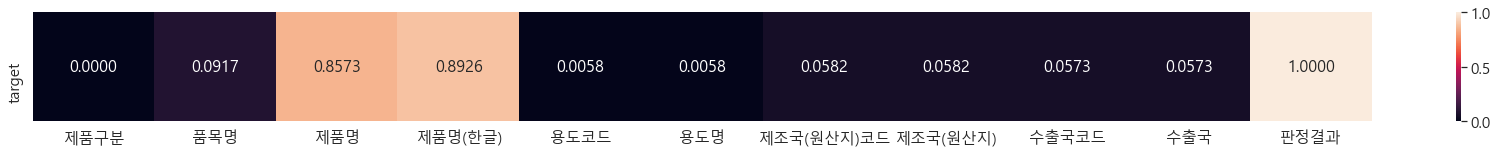

In [115]:
cat_corr(data_02)

In [117]:
summary(data_02)

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
제품구분,object,0,0.0,1,['가공식품']
품목명,object,0,0.0,318,['기타가공품' '서류가공품' '청주' '소스류' '과실주']
제품명,object,1,0.0,135025,['GUARANA EXTRACT POWDER' 'CAVENDISH STRAIGHT ...
제품명(한글),object,0,0.0,154038,['과라나추출분말' '스트레이트 컷' '간바래 오도상팩(900미리리터)' '정제뉴러...
용도코드,object,0,0.0,9,['1' 'J' '4' 'H' '7']
용도명,object,0,0.0,9,['판매용' '자사제품제조용' '외화획득용 원료' '판매용(식용향료)' '반송품(기...
제조국(원산지)코드,object,1,0.0,137,['US' 'CA' 'JP' 'CN' 'FR']
제조국(원산지),object,0,0.0,138,['미국' '캐나다' '일본' '중국' '프랑스']
수출국코드,object,1,0.0,135,['US' 'CA' 'JP' 'CN' 'FR']
수출국,object,0,0.0,136,['미국' '캐나다' '일본' '중국' '프랑스']


### 제픔명과 제품명(한글)은 High cardinaliry를 가진 범주형변수로 전처리 대신 지우기(그냥)

In [120]:
df = data_02.drop(['제품명', '제품명(한글)'], axis=1).copy()
df

,제품구분,품목명,용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,
20160121820,가공식품,기타가공품,1,판매용,US,미국,US,미국,반려
201600214072,가공식품,서류가공품,1,판매용,CA,캐나다,CA,캐나다,적합
201600217150,가공식품,청주,1,판매용,JP,일본,JP,일본,적합
201600231480,가공식품,소스류,1,판매용,CN,중국,CN,중국,적합
20160085048,가공식품,과실주,1,판매용,FR,프랑스,FR,프랑스,적합
...,...,...,...,...,...,...,...,...,...
202100503748,가공식품,과실주,1,판매용,RO,루마니아,RO,루마니아,적합
202100512590,가공식품,과실주,1,판매용,NZ,뉴질랜드,NZ,뉴질랜드,적합
202100350520,가공식품,과실주,1,판매용,FR,프랑스,FR,프랑스,적합


In [122]:
summary(df)
df.shape

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
제품구분,object,0,0.0,1,['가공식품']
품목명,object,0,0.0,318,['기타가공품' '서류가공품' '청주' '소스류' '과실주']
용도코드,object,0,0.0,9,['1' 'J' '4' 'H' '7']
용도명,object,0,0.0,9,['판매용' '자사제품제조용' '외화획득용 원료' '판매용(식용향료)' '반송품(기...
제조국(원산지)코드,object,1,0.0,137,['US' 'CA' 'JP' 'CN' 'FR']
제조국(원산지),object,0,0.0,138,['미국' '캐나다' '일본' '중국' '프랑스']
수출국코드,object,1,0.0,135,['US' 'CA' 'JP' 'CN' 'FR']
수출국,object,0,0.0,136,['미국' '캐나다' '일본' '중국' '프랑스']
판정결과,object,0,0.0,6,['반려' '적합' '부적합' '자진 취하' '부적합처분 취소(철회)에 따른 재검사...


(184994, 9)

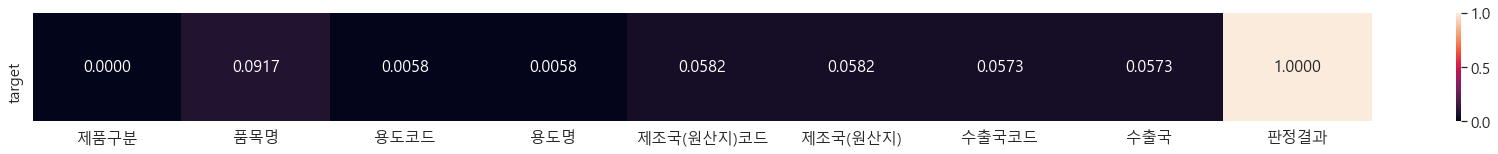

In [126]:
columns = df.columns
theilu = pd.DataFrame(index=['target'], columns= columns)
cat_corr(df)

### 한번도 부적합 전혀 없는 품목은? 데이터에서 제거할까?

In [139]:
df = df[(df['판정결과'] == '적합') | (df['판정결과'] == '부적합') | (df['판정결과'] == '반려')]
df.판정결과 = df.판정결과.map({'적합' :0, '부적합': 1, '반려': 1})

In [140]:
df.판정결과.value_counts()

0    180534
1      3064
Name: 판정결과, dtype: int64

In [141]:
not_unfit_ever = df.groupby('품목명')['판정결과'].mean()[df.groupby('품목명')['판정결과'].mean() == 0].index
type(not_unfit_ever)
not_unfit_ever = list(not_unfit_ever)
'/'.join(not_unfit_ever)

pandas.core.indexes.base.Index

'가공두유/갈락토올리고당/갈색설탕/감자전분/개량메주/건조효모제품/결정과당/고구마전분/고올레산홍화유/고추씨기름/고추장/과.채페이스트/과.채퓨레/과.채퓨레.페이스트/과당/과자(유밀과)/과자(한과류)/기타 건포류/기타 코코아가공품/기타가공품(식용번데기가공품)/기타건포류/기타과당/기타두유/기타면류/기타면류(수제비)/기타밀가루/기타설탕/기타엿/기타올리고당/기타잼/김칫속/냉면/농축과,채즙(또는과.채분)/농축과.채즙(또는 과채분)/당시럽류/대두분/덱스트린/동결건조로얄젤리/된장/두유/두유액/드레싱/들기름/땅콩기름/땅콩기름(낙화생유)/떡류/로얄젤리제품/마멀레이드/모조치즈/목화씨기름(면실유)/묵류/물엿/밀가루/배아효소함유제품/백설탕/벌집꿀/분말.결정포도당/분말두유/빵류(도넛)/빵류(식빵)/빵류(파이)/빵류(피자)/빵류(핫도그)/생식제품/성장기용조제식/소주/쇼트닝/수산물조림/식육함유가공품/식초절임(매실절임)/식초절임(생강절임)/식해류/신선편의식품/알함유가공품/액상과당/액젓/어육반제품/어육살/어육소시지/연하곤란환자용 점도증진식품/열량 및 영양공급용 식품/열량 및 영양공급용 의료용도식품/영.유아용 특수조제식품/영?유아용 특수조제식품/영아용조제식/영양강화밀가루/옥수수기름(옥배유)/올리고당가공품/원액두유/유바/유함유가공품/인삼.홍삼음료/임산.수유부용식품/자라유제품/자일로올리고당제/재래한식간장/재제소금(재제조소금)/저지방마가린(지방스프레드)/전분/정제,가공을거쳐야하는식품원료/정제소금/정제올리브유/조림류/조미김/조미된장/주정/즉석섭취식품/찐쌀/채종유(유채유또는카놀라유)/청국장/추잉껌/추출가공식품/추출식품/춘장/캔디류(양갱)/캔디류(캐러멜)/커피/커피(기타)/코코아매스/코코아버터/코코아분말/태움.용융소금/팜스테아린유/팜올레인유/팜유/팜핵유/팝콘용옥수수가공품/패밀리밀크초콜릿/포도당/프락토올리고당/한식된장/한식메주/향신료조제품(겨자가공품)/현치사포도 잎(식품원료 한시기준 2016-4호)/혼합간장/홍화유(사플라워유 또는 잇꽃유)/화분제품/화분추출물제품/화이트초콜릿/효모식품/효모추출물제품'

In [147]:
count = 0
for i in not_unfit_ever:
    count = count + df[df['품목명'] == '가공두유']['판정결과'].sum()
count

0

In [151]:
df[df['품목명'].isin(not_unfit_ever)]

,제품구분,품목명,용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,
201600243661,가공식품,냉면,1,판매용,JP,일본,JP,일본,0
201600171719,가공식품,캔디류(양갱),1,판매용,JP,일본,JP,일본,0
20151349502,가공식품,캔디류(캐러멜),1,판매용,SG,싱가포르,SG,싱가포르,0
20160111962,가공식품,캔디류(캐러멜),1,판매용,JP,일본,JP,일본,0
20160086718,가공식품,조미김,1,판매용,TH,태국,IT,이탈리아,0
...,...,...,...,...,...,...,...,...,...
202100497824,가공식품,밀가루,1,판매용,IT,이탈리아,IT,이탈리아,0
202100410799,가공식품,어육살,1,판매용,ID,인도네시아,ID,인도네시아,0
202100510837,가공식품,유바,1,판매용,CN,중국,CN,중국,0


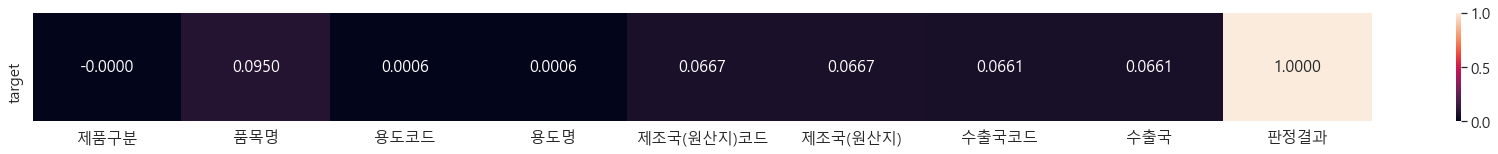

In [154]:
cat_corr(df[~df['품목명'].isin(not_unfit_ever)])

In [155]:
summary(df[~df['품목명'].isin(not_unfit_ever)])

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
제품구분,object,0,0.0,1,['가공식품']
품목명,object,0,0.0,174,['기타가공품' '서류가공품' '청주' '소스류' '과실주']
용도코드,object,0,0.0,9,['1' 'J' '4' 'H' 'G']
용도명,object,0,0.0,9,['판매용' '자사제품제조용' '외화획득용 원료' '판매용(식용향료)' '반송품(국...
제조국(원산지)코드,object,1,0.0,136,['US' 'CA' 'JP' 'CN' 'FR']
제조국(원산지),object,0,0.0,137,['미국' '캐나다' '일본' '중국' '프랑스']
수출국코드,object,1,0.0,135,['US' 'CA' 'JP' 'CN' 'FR']
수출국,object,0,0.0,136,['미국' '캐나다' '일본' '중국' '프랑스']
판정결과,int64,0,0.0,2,[1 0]


Text(-0.35000000000000003, 170384.0, '170374')

Text(0.6500000000000001, 3488.0, '3478')

Text(1.6500000000000001, 190.0, '180')

Text(2.6499999999999995, 12.0, '2')

Text(3.6499999999999995, 29.0, '19')

...

Text(4.05, 10, '0')

Text(5.05, 10, '0')

Text(6.05, 12.0, '2')

Text(7.05, 10, '0')

Text(8.049999999999999, 10, '0')

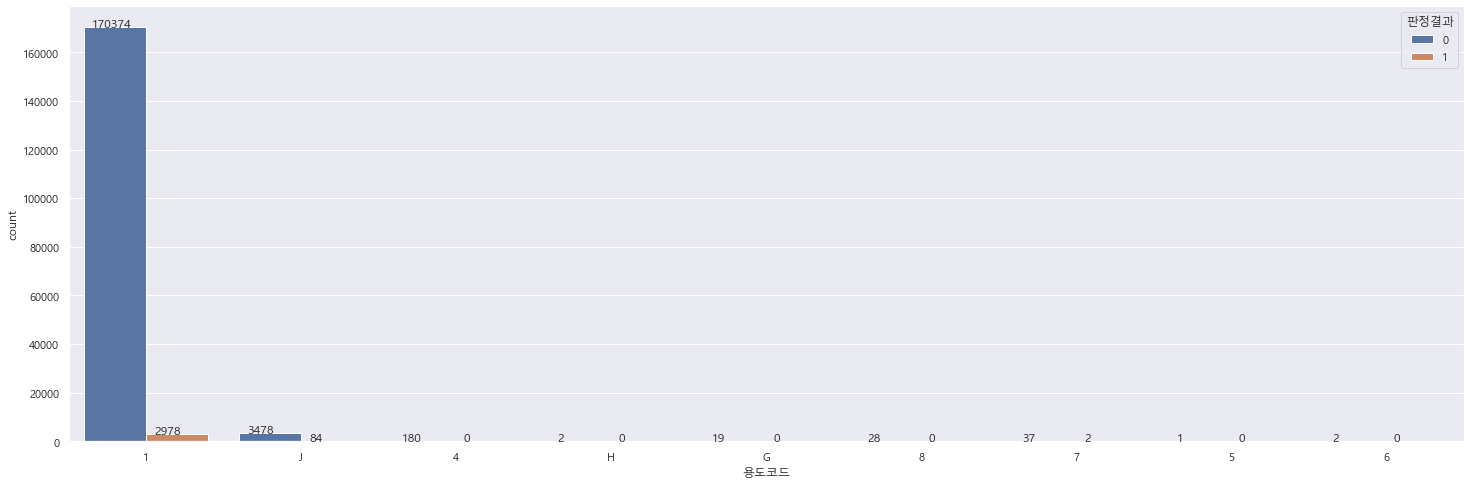

In [159]:
sns.set(rc={'figure.figsize':(25,8)})
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 표시
plt.rcParams['axes.unicode_minus'] = False  #한글 폰트 사용시 마이너스 폰트 깨짐 해결

ax=sns.countplot(x='용도코드',hue='판정결과',data=df[~df['품목명'].isin(not_unfit_ever)])
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.05, patch_height+10))
plt.show()

## 판정결과가 '0'과 '1'이 섞여있는 데이터만 예측하면 안되나?
- 즉 용도코드가 4, H, G, 8, 5, 6 인 데이터는 적합데이터만 존재

In [161]:
data = df[~df['품목명'].isin(not_unfit_ever)]
data[data.용도코드 == 'H']

,제품구분,품목명,용도코드,용도명,제조국(원산지)코드,제조국(원산지),수출국코드,수출국,판정결과
접수번호,,,,,,,,,
20160036836,가공식품,향미유,H,판매용(식용향료),FR,프랑스,FR,프랑스,0
201800474884,가공식품,혼합식용유,H,판매용(식용향료),JP,일본,JP,일본,0


## Further Study